# XGBoost Analysis with Feather File

This notebook demonstrates how to read a feather file and fit an XGBoost model.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Read Feather File

In [ ]:
file_path = 'https://raw.githubusercontent.com/axspinnacle/cfs25/main/data/'
file_name = 'data5.ftr'
if 0:  
    file_path = '/Users/ML/dev/aps/code/cfs25/ftr_data/'
    file_name = 'data5.ftr'

try:
    # Read the feather file
    df_ini = pd.read_feather(file_path + file_name)
    print(f"Data loaded successfully!")
    print(f"Shape: {df_ini.shape}")
    print(f"\nColumns: {list(df_ini.columns)}")
except FileNotFoundError:
    print(f"File '{file_path}' not found. Please check the file path.")
    # Create sample data for demonstration
    print("Creating sample data for demonstration...")
    np.random.seed(42)
    n_samples = 1000
    df_ini = pd.DataFrame({
        'feature1': np.random.normal(0, 1, n_samples),
        'feature2': np.random.normal(2, 0.5, n_samples),
        'feature3': np.random.randint(0, 5, n_samples),
        'feature4': np.random.exponential(1, n_samples),
        'target': np.random.randint(0, 3, n_samples)  # Multi-class target
    })
    print(f"Sample data created with shape: {df_ini.shape}")
    


Data loaded successfully!
Shape: (100443, 66)

Columns: ['pol_eff_year', 'ep_bi', 'ep_col', 'ee_bi', 'ee_col', 'incloss_bi', 'incloss_col', 'cc_bi', 'cc_col', 'zip', 'pol_id', 'vin_id', 'credit', 'commute_flag', 'veh_count_box', 'driver_count_box', 'veh_age_box', 'coll_symb_ntile', 'limit_bi', 'ded_coll', 'DrvAge_box', 'male', 'single', 'widowed', 'Date', 'Modeled_Annual_Mileage', 'Estimated_Current_Mileage', 'Annual_Mileage_Estimate', 'Number_of_Titling_Transactions', 'Lien_Holder', 'current_ownership_personal', 'current_ownership_lease', 'current_ownership_corp_govt', 'LOO_years', 'personal_use_flag', 'rental_use_flag', 'comm_use_flag', 'fleet_use_flag', 'corp_use_flag', 'lease_flag', 'curr_owner_odo_cnt', 'all_owner_odo_cnt', 'Severe_Problem_flag', 'Branded_Title_flag', 'Branded_Title_Loss_flag', 'Severe_Accident_flag', 'Other_Severe_Problem_flag', 'Failed_Emissions_flag', 'Nonsevere_Accident_flag', 'Damage_flag', 'Collision_Repair_Facility_flag', 'Potential_Damage_flag', 'Odometer_

In [5]:
#In case we mess up something, we dont have to reload. Rerun this command. 
df = df_ini.copy()

## Explore the Data

In [6]:
# Display basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100443 entries, 0 to 100442
Data columns (total 66 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   pol_eff_year                              100443 non-null  uint16 
 1   ep_bi                                     100443 non-null  float64
 2   ep_col                                    100443 non-null  float64
 3   ee_bi                                     100443 non-null  float64
 4   ee_col                                    100443 non-null  float64
 5   incloss_bi                                100443 non-null  float64
 6   incloss_col                               100443 non-null  float64
 7   cc_bi                                     100443 non-null  uint8  
 8   cc_col                                    100443 non-null  uint8  
 9   zip                                       100443 non-null  uint16 
 10  pol_id

In [7]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Missing values:
pol_eff_year                                0
ep_bi                                       0
ep_col                                      0
ee_bi                                       0
ee_col                                      0
                                           ..
Annual_Mileage_Estimate_null_flag           0
Number_of_Titling_Transactions_null_flag    0
LOO_years_null_flag                         0
curr_owner_odo_cnt_null_flag                0
all_owner_odo_cnt_null_flag                 0
Length: 66, dtype: int64

Data types:
pol_eff_year                                 uint16
ep_bi                                       float64
ep_col                                      float64
ee_bi                                       float64
ee_col                                      float64
                                             ...   
Annual_Mileage_Estimate_null_flag             uint8
Number_of_Titling_Transactions_null_flag      uint8
LOO_years_null_flag     

## Prepare Data for XGBoost

In [8]:
other_cols_to_remove = ['ep_bi', 'ep_col', 'ee_bi', 'ee_col', 'incloss_bi', 'incloss_col', 'cc_bi', 'zip', 'pol_id', 'vin_id','Date']
df = df.drop(columns=other_cols_to_remove)

In [9]:
# You'll need to specify which column is your target variable
# For this example, we'll assume the last column is the target
# Adjust this based on your actual data

# Identify target column (modify as needed)
target_column = "cc_col" # Assuming last column is target
print(f"Using '{target_column}' as target variable")

# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:")
print(y.value_counts())

Using 'cc_col' as target variable
Features shape: (100443, 54)
Target shape: (100443,)
Target distribution:
cc_col
0    98418
1     1977
2       40
3        5
8        1
6        1
4        1
Name: count, dtype: int64


In [ ]:
# Handle categorical variables if any
categorical_columns = X.select_dtypes(include=['object', 'category']).columns
if len(categorical_columns) > 0:
    print(f"Categorical columns found: {list(categorical_columns)}")
    # Apply label encoding to categorical variables
    le = LabelEncoder()
    for col in categorical_columns:
        X[col] = le.fit_transform(X[col])
    print("Categorical variables encoded")
else:
    print("No categorical variables found")

# Handle missing values if any
if X.isnull().sum().sum() > 0:
    print("Filling missing values with median...")
    X = X.fillna(X.median())
    print("Missing values handled")

No categorical variables found


## Train-Test Split

In [11]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training target distribution:")
print(y_train.value_counts())

Training set shape: (80354, 54)
Test set shape: (20089, 54)
Training target distribution:
cc_col
0    78747
1     1564
2       35
3        5
6        1
4        1
8        1
Name: count, dtype: int64


## Fit XGBoost Model

In [12]:
# Determine if this is a classification or regression problem
is_classification = len(y.unique()) < 20 and y.dtype in ['int64', 'object', 'category']

if is_classification:
    print("Detected classification problem")
    # XGBoost Classifier
    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss' if len(y.unique()) > 2 else 'logloss'
    )
else:
    print("Detected regression problem")
    # XGBoost Regressor
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

# Fit the model
print("Training XGBoost model...")
model.fit(X_train, y_train)
print("Model training completed!")

Detected regression problem
Training XGBoost model...
Model training completed!


## Make Predictions and Evaluate

In [13]:
# Make predictions
y_pred = model.predict(X_test)

if is_classification:
    # Classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
else:
    # Regression metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

Mean Squared Error: 0.0214
Root Mean Squared Error: 0.1462
R² Score: -0.0119


## Feature Importance

Feature Importance:
                                     feature  importance
26                             corp_use_flag    0.037299
7                                   limit_bi    0.034411
3                              veh_count_box    0.030551
27                                lease_flag    0.030302
1                                     credit    0.028243
19                   current_ownership_lease    0.027119
0                               pol_eff_year    0.026988
15                   Annual_Mileage_Estimate    0.026273
46                        unemployment_ntile    0.025158
49         Annual_Mileage_Estimate_null_flag    0.025031
17                               Lien_Holder    0.023210
28                        curr_owner_odo_cnt    0.022801
5                                veh_age_box    0.022770
36                   Nonsevere_Accident_flag    0.022474
14                 Estimated_Current_Mileage    0.022283
23                           rental_use_flag    0.022083
16         

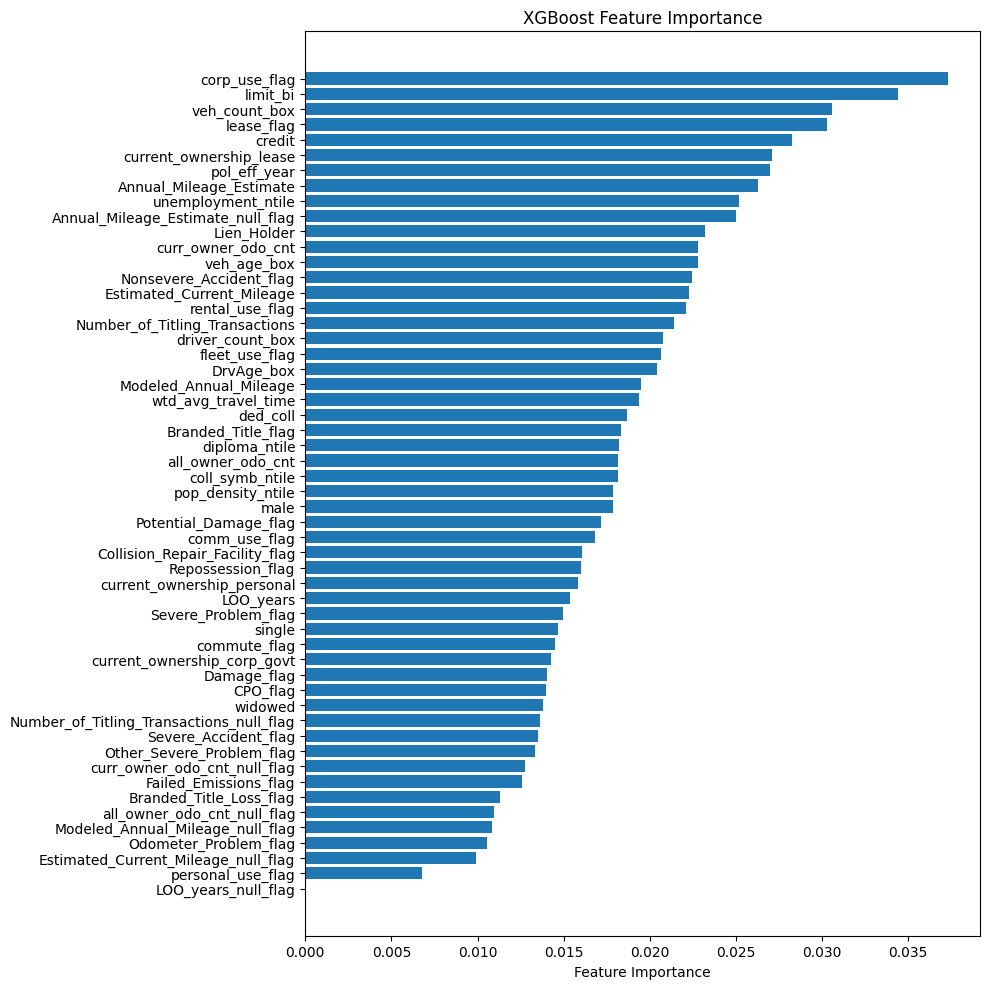

In [22]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Plot feature importance (optional - requires matplotlib)
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 10))
    plt.barh(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Feature Importance')
    plt.title('XGBoost Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Matplotlib not available for plotting")

## Model Summary

In [15]:
print("=== Model Summary ===")
print(f"Model type: {type(model).__name__}")
print(f"Number of features: {X.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Problem type: {'Classification' if is_classification else 'Regression'}")

if is_classification:
    print(f"Number of classes: {len(y.unique())}")
    print(f"Test accuracy: {accuracy:.4f}")
else:
    print(f"Test R² score: {r2:.4f}")
    print(f"Test RMSE: {rmse:.4f}")

print("\nTop 3 most important features:")
for i, (idx, row) in enumerate(feature_importance.head(3).iterrows()):
    print(f"{i+1}. {row['feature']}: {row['importance']:.4f}")

=== Model Summary ===
Model type: XGBRegressor
Number of features: 54
Training samples: 80354
Test samples: 20089
Problem type: Regression
Test R² score: -0.0119
Test RMSE: 0.1462

Top 3 most important features:
1. corp_use_flag: 0.0373
2. limit_bi: 0.0344
3. veh_count_box: 0.0306
